<a href="https://colab.research.google.com/github/stacykeago/predictive-data-analytics/blob/main/q1136017_keago.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Define the question:
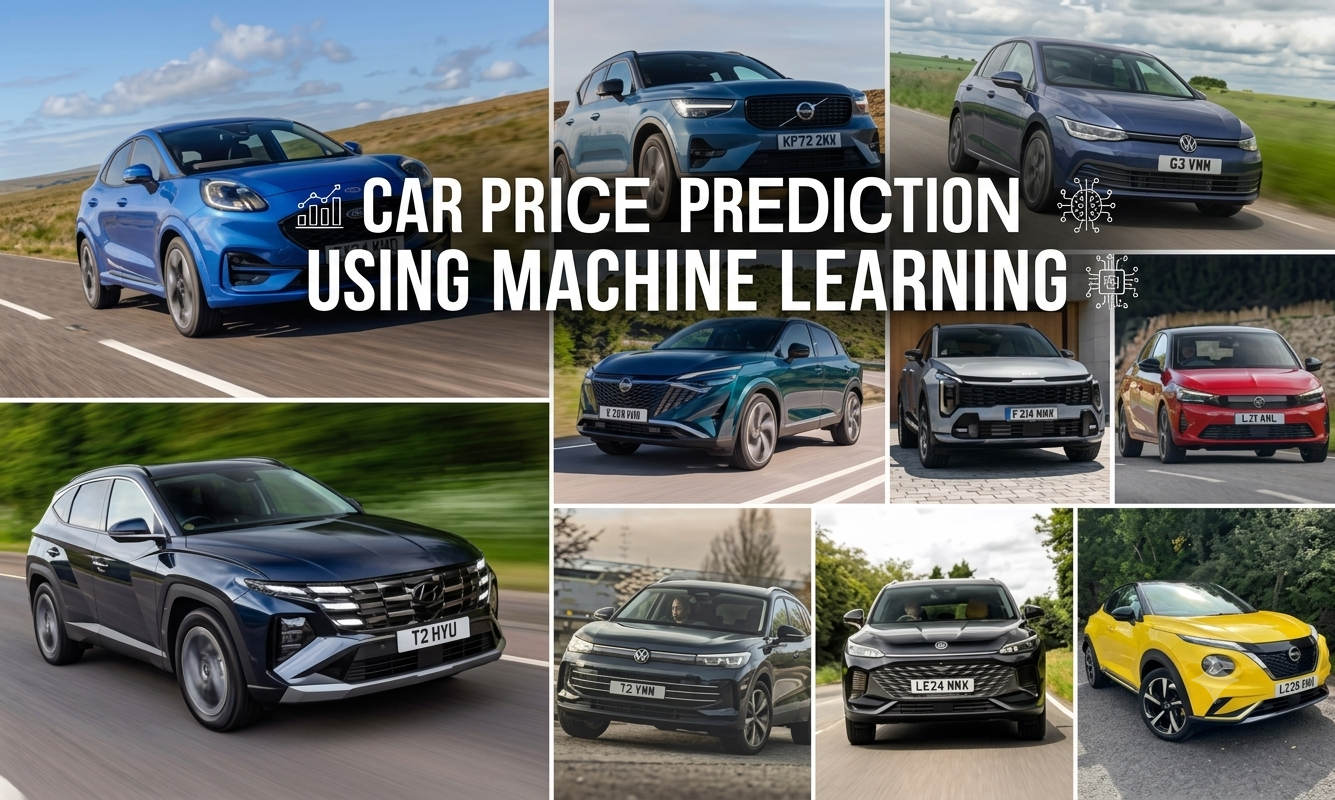

# Metric of success
The predictive accuracy of the car price models is evaluated based on key performance indicators (KPIs) designed for machine learning regression tasks. These metrics measure the deviation between the predicted values and the actual market prices.

1. R-squared (R 2   Score)

2. Mean Absolute Error (MAE)

3. Root Mean Squared Error (RMSE)

4. Residual Analysis (Error Distribution)

Resources that support this analysis
1. [Report](https://docs.google.com/document/d/1f9NFLPV1McGwowtARDlbhjBZPAOGAa9H/edit)


# a. EXPLORATORY DATA ANALYSIS (EDA)

## 1.0 Import the libraries to be used

In [ ]:
import numpy as np # for linear algebra
import pandas as pd # for data processing
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
from sklearn.preprocessing import LabelEncoder # the libraries for label encoding
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## 2.0 Upload Dataset

In [ ]:
# 1. Force pandas to display ALL columns and rows without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv'

auto = pd.read_csv(url, header=None)

# 2. Define the correct column names for this specific IBM dataset
headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type","num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

# 3. Assign the columns to dataframe
auto.columns = headers

# preview 10 rows
auto.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,52.0,3053,ohc,five,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


### 2.1 Column names

In [ ]:
auto.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'], dtype='object')

### 2.2 Number of rows and columns



In [ ]:
# Print number of rows and columns
print(f"Rows: {auto.shape[0]}, Columns: {auto.shape[1]}")

Rows: 205, Columns: 26


### 2.3 Data types in each column

In [ ]:
# Fixed layout with explicit column names
half = len(auto.dtypes) // 2
df1 = auto.dtypes.iloc[:half].reset_index()
df2 = auto.dtypes.iloc[half:].reset_index()

df_merged = pd.concat([df1, df2], axis=1)
df_merged.columns = ["Column_1", "Data_type", "Column_2",   "   Data _type"]
df_merged.fillna("")

,Column_1,Data_type,Column_2,Data _type
0,symboling,int64,curb-weight,int64
1,normalized-losses,object,engine-type,object
2,make,object,num-of-cylinders,object
3,fuel-type,object,engine-size,int64
4,aspiration,object,fuel-system,object
5,num-of-doors,object,bore,object
6,body-style,object,stroke,object
7,drive-wheels,object,compression-ratio,float64
8,engine-location,object,horsepower,object
9,wheel-base,float64,peak-rpm,object


### 2.4 Statistical summary of the data

In [ ]:
auto.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


### 2.5 Null values / missing values




#### a. check if columns have symbols

In [ ]:
for col in auto.columns:
    count = auto[col].astype(str).str.contains(r'[^a-zA-Z0-9\s.]', na=False).sum()
    if count > 0:
        print(f"Column '{col}' has {count} rows with symbols.")

Column 'symboling' has 25 rows with symbols.
Column 'normalized-losses' has 41 rows with symbols.
Column 'make' has 11 rows with symbols.
Column 'num-of-doors' has 2 rows with symbols.
Column 'bore' has 4 rows with symbols.
Column 'stroke' has 4 rows with symbols.
Column 'horsepower' has 2 rows with symbols.
Column 'peak-rpm' has 2 rows with symbols.
Column 'price' has 4 rows with symbols.


In [ ]:
# 1. Replace missing data symbols with NaN
auto.replace("?", np.nan, inplace=True)

# 2. Drop rows where price is missing (NaN)
auto.dropna(subset=["price"], axis=0, inplace=True)

# 3. Convert data types to float
cols_to_convert = ["bore", "stroke", "peak-rpm", "horsepower", "price"]
auto[cols_to_convert] = auto[cols_to_convert].astype(float)

#### Handle missing values

In [ ]:
# 4. Handle the continuous numeric columns using MEDIAN
numeric_cols_to_impute = ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm"]
for col in numeric_cols_to_impute:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")
    # Directly reassign the column without using inplace=True
    auto[col] = auto[col].fillna(auto[col].median())

# 5. Handle the categorical column using MODE
auto["num-of-doors"] = auto["num-of-doors"].fillna(auto["num-of-doors"].mode()[0])

# 6. Verify clean results
print(auto[numeric_cols_to_impute + ["num-of-doors"]].isnull().sum())

normalized-losses    0
bore                 0
stroke               0
horsepower           0
peak-rpm             0
num-of-doors         0
dtype: int64


### 2.6 Duplicates

In [ ]:
#check for duplicates : Duplicates are noise to the data
np.sum(auto.duplicated())

np.int64(0)

### 2.7 Unique features in the data

In [ ]:
# count of unique values for each column in the DataFrame.
auto.nunique()

,0
symboling,6
normalized-losses,51
make,22
fuel-type,2
aspiration,2
num-of-doors,2
body-style,5
drive-wheels,3
engine-location,2
wheel-base,52


### 2.8 Outliers

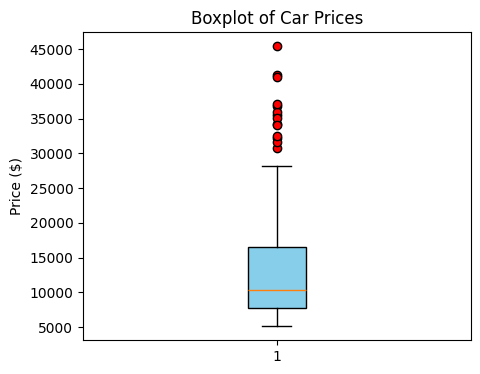

In [ ]:
# Force numeric extraction and drop missing values to prevent execution crashes
clean_prices = pd.to_numeric(auto["price"], errors="coerce").dropna()

plt.figure(figsize=(5, 4))
plt.boxplot(clean_prices, patch_artist=True,
            boxprops=dict(facecolor="skyblue", color="black"),
            flierprops=dict(markerfacecolor="red", marker="o"))
plt.title("Boxplot of Car Prices")
plt.ylabel("Price ($)")
plt.show()

# b. STATISTICAL SUMMARY

## 3.0 Data summary

In [ ]:
auto.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,120.711443,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330299,3.257562,10.164279,103.313433,5118.407960,25.179104,30.686567,13207.129353
std,1.254802,32.111623,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.268088,0.316082,4.004965,37.374942,478.183493,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,137.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


## 3.1 Univariate Analysis

In [ ]:
auto.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'], dtype='object')

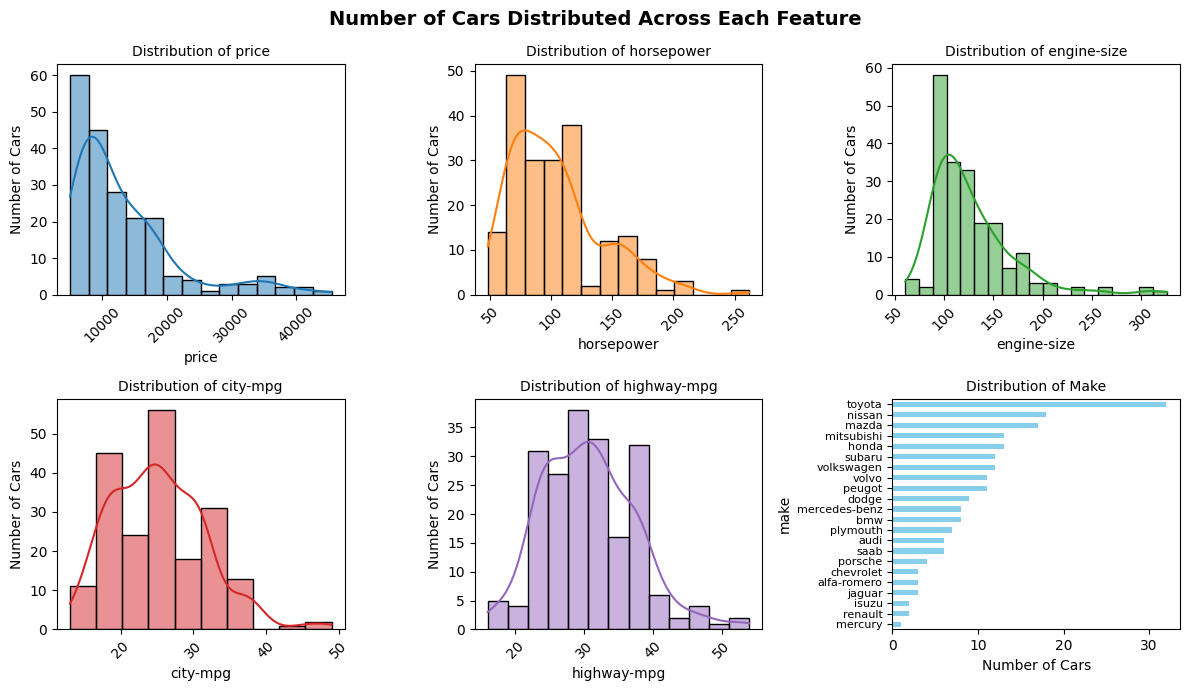

In [ ]:
col_dict = {"price": 1, "horsepower": 2, "engine-size": 3, "city-mpg": 4, "highway-mpg": 5}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

plt.figure(figsize=(12, 7))

# Added main title to describe the frequency/number of cars across features
plt.suptitle("Number of Cars Distributed Across Each Feature", fontsize=14, fontweight='bold', y=0.98)

for idx, (variable, i) in enumerate(col_dict.items()):
    plt.subplot(2, 3, i)
    sns.histplot(auto[variable].dropna(), kde=True, color=colors[idx])
    plt.title(f"Distribution of {variable}", fontsize=10)
    plt.ylabel("Number of Cars") # Added y-label to explicitly show count
    plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
auto['make'].value_counts().plot(kind='barh', color='skyblue').invert_yaxis()
plt.title("Distribution of Make", fontsize=10)
plt.xlabel("Number of Cars")
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

## 3.2 Bivariate Analysis

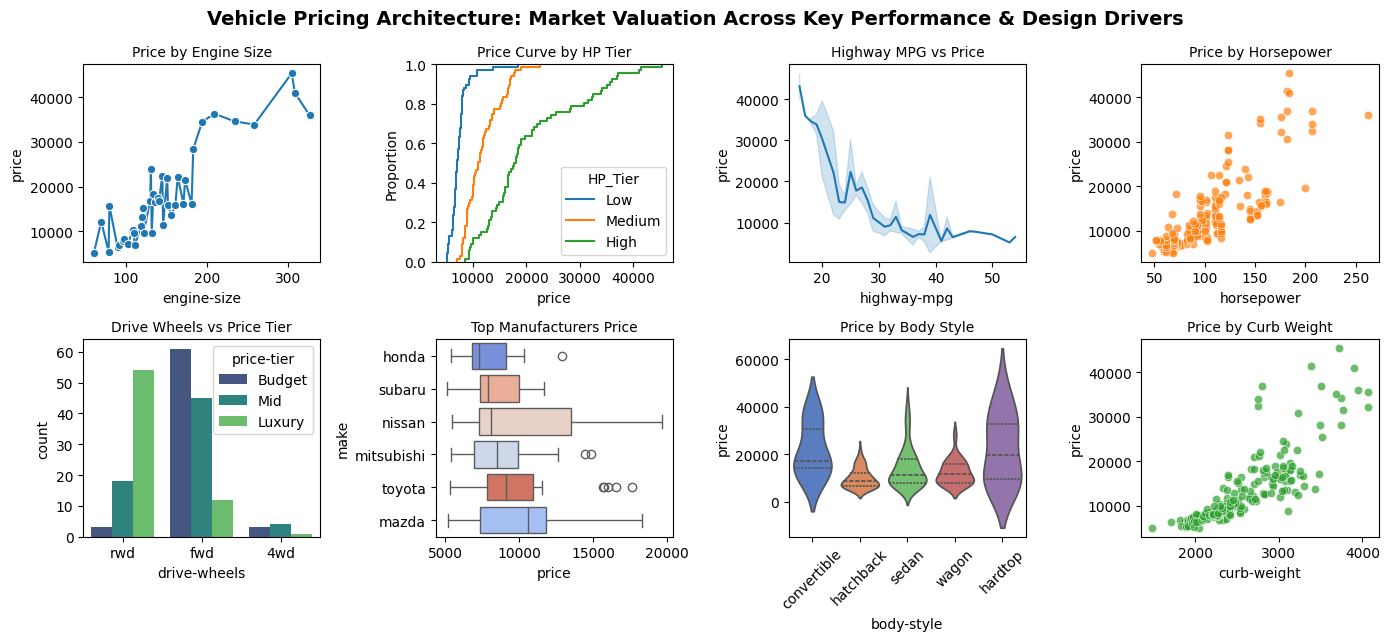

In [ ]:
# 1. create a data frame
df = auto.copy()
df["HP_Tier"] = pd.qcut(df["horsepower"], q=3, labels=["Low", "Medium", "High"])
df["price-tier"] = pd.qcut(df["price"], q=3, labels=["Budget", "Mid", "Luxury"])

# 2. Filter Top Makes for Boxplot
top_m = df["make"].value_counts().nlargest(6).index
df_m = df[df["make"].isin(top_m)]

# 3. Layout Config
fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))
axes = axes.flatten()

plt.suptitle("Vehicle Pricing Architecture: Market Valuation Across Key Performance & Design Drivers", fontsize=14, fontweight="bold", y=0.98)

cfg = [
    (sns.lineplot, {"data": df, "x": "engine-size", "y": "price", "marker": "o", "errorbar": None}, "Price by Engine Size"),
    (sns.ecdfplot, {"data": df, "x": "price", "hue": "HP_Tier"}, "Price Curve by HP Tier"),
    (sns.lineplot, {"data": df, "x": "highway-mpg", "y": "price", "errorbar": "sd"}, "Highway MPG vs Price"),
    (sns.scatterplot, {"data": df, "x": "horsepower", "y": "price", "alpha": 0.7, "color": "#ff7f0e"}, "Price by Horsepower"),
    (sns.countplot, {"data": df, "x": "drive-wheels", "hue": "price-tier", "palette": "viridis"}, "Drive Wheels vs Price Tier"),
    (sns.boxplot, {"data": df_m, "x": "price", "y": "make", "hue": "make", "legend": False, "palette": "coolwarm", "order": df_m.groupby("make")["price"].median().sort_values().index}, "Top Manufacturers Price"),
    (sns.violinplot, {"data": df, "x": "body-style", "y": "price", "hue": "body-style", "legend": False, "palette": "muted", "inner": "quart"}, "Price by Body Style"),
    (sns.scatterplot, {"data": df, "x": "curb-weight", "y": "price", "alpha": 0.7, "color": "#2ca02c"}, "Price by Curb Weight")
]

for idx, (func, kwargs, title) in enumerate(cfg):
    func(ax=axes[idx], **kwargs)
    axes[idx].set_title(title, fontsize=10)
    if idx == 6: axes[idx].tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.show()

## 3.3 Multivariate Analysis

In [ ]:
auto.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'], dtype='object')

In [ ]:
# list of all categorical column names
categorical_cols = auto.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns in the dataset:")
print(categorical_cols)

Categorical columns in the dataset:
['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']


In [ ]:
# 1. Select only  numeric
numeric_df = auto.select_dtypes(include=['number'])

# 2. Get correlation
price_corr = numeric_df.corr()['price'].drop('price')

# 3. Sort by absolute strength to find most relevant columns
top_correlated = price_corr.abs().sort_values(ascending=False)

# Display the top features and their actual correlation values
print("Columns most correlated to price:")
print(price_corr[top_correlated.index])

Columns most correlated to price:
engine-size          0.872335
curb-weight          0.834415
horsepower           0.810500
width                0.751265
highway-mpg         -0.704692
length               0.690628
city-mpg            -0.686571
wheel-base           0.584642
bore                 0.543158
height               0.135486
peak-rpm            -0.102310
normalized-losses    0.094366
symboling           -0.082391
stroke               0.082209
compression-ratio    0.071107
Name: price, dtype: float64


notes:  columns with NAN are categorical columns

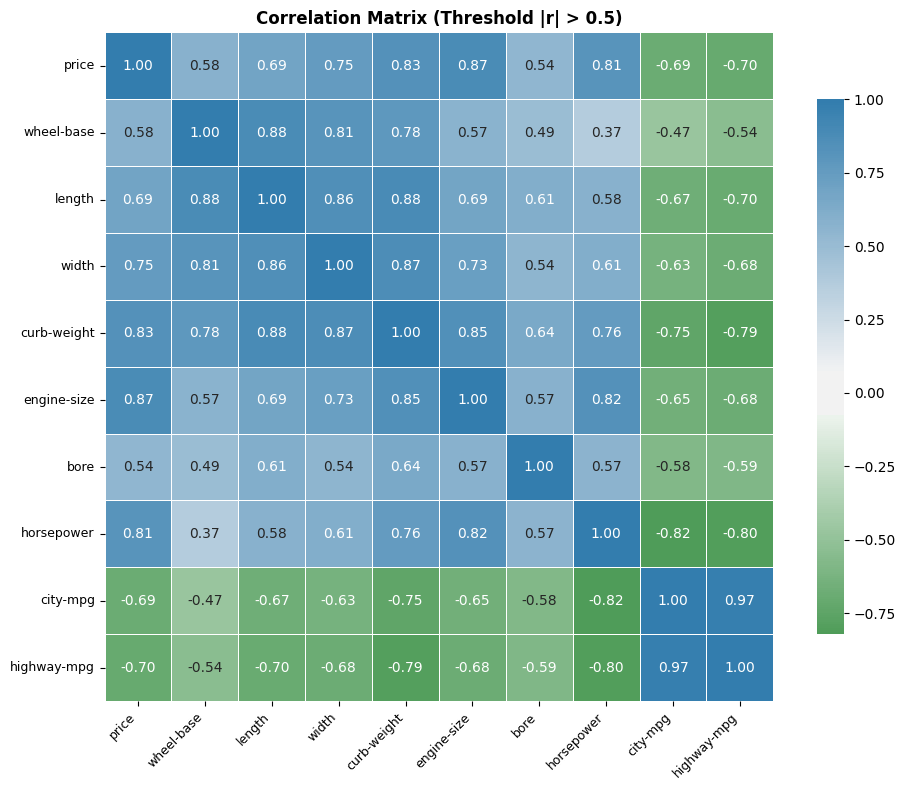

In [ ]:
# 1. Select columns with absolute correlation above 0.5
strong_features = price_corr[price_corr.abs() > 0.5].index.tolist()
relevant_cols = ["price"] + strong_features

# 2. Compute the correlation matrix
corr_matrix = numeric_df[relevant_cols].corr()

# Create a custom palette: Green (negative), Orange/Yellow (mid), Blue (positive)
custom_cmap = sns.diverging_palette(130, 240, s=85, l=50, sep=20, center="light", as_cmap=True)

# Added cbar_kws for clean scale labels and rotated tick labels to prevent text overlapping
plt.figure(figsize=(10, 8)); sns.heatmap(corr_matrix, annot=True, cmap=custom_cmap, center=0, fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix (Threshold |r| > 0.5)", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300) # Increased DPI for a crisp report image
plt.show()

# c. DATA PROCESSING AND FEATURE ENGINEERING

##### Feature engineering

###### introduce a new feature

In [ ]:
# 1. Create the new engineered metric feature
auto["city-L/100km"] = 235 / auto["city-mpg"]


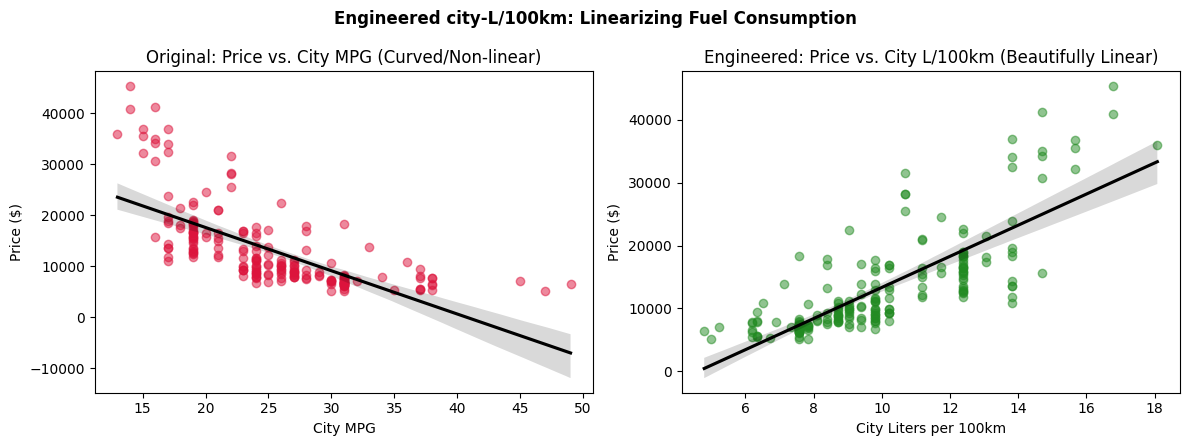

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Engineered city-L/100km: Linearizing Fuel Consumption", fontsize=12, fontweight="bold")

# Plot 1: Old non-linear relationship
sns.regplot(data=auto, x="city-mpg", y="price", ax=axes[0], color="crimson", scatter_kws={'alpha':0.5}, line_kws={'color':'black'})
axes[0].set_title("Original: Price vs. City MPG (Curved/Non-linear)")
axes[0].set_xlabel("City MPG")
axes[0].set_ylabel("Price ($)")

# Plot 2: New linear relationship
sns.regplot(data=auto, x="city-L/100km", y="price", ax=axes[1], color="forestgreen", scatter_kws={'alpha':0.5}, line_kws={'color':'black'})
axes[1].set_title("Engineered: Price vs. City L/100km (Beautifully Linear)")
axes[1].set_xlabel("City Liters per 100km")
axes[1].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

###### Binning

In [ ]:
# Step 1: Feature Engineering (Apply Binning )
bins = np.linspace(auto["horsepower"].min(), auto["horsepower"].max(), 4)
auto["horsepower_binned"] = pd.cut(auto["horsepower"], bins=bins, labels=["Low", "Medium", "High"], include_lowest=True)

# Step 2: Feature Selection & Dropping
categorical_features = ["drive-wheels", "body-style"]

/tmp/ipykernel_15858/386675328.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=auto, x="horsepower_binned", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_15858/386675328.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=auto, x="horsepower_binned", y="price", ax=axes[1], palette="Purples")


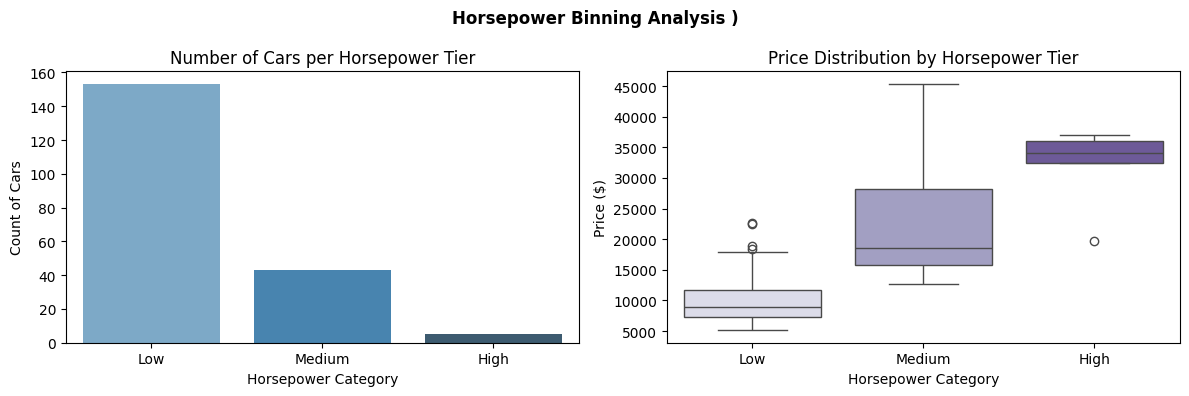

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Horsepower Binning Analysis )", fontsize=12, fontweight="bold")

# Plot 1: Count of cars in each horsepower tier
sns.countplot(data=auto, x="horsepower_binned", ax=axes[0], palette="Blues_d")
axes[0].set_title("Number of Cars per Horsepower Tier")
axes[0].set_xlabel("Horsepower Category")
axes[0].set_ylabel("Count of Cars")

# Plot 2: Price distribution across the tiers
sns.boxplot(data=auto, x="horsepower_binned", y="price", ax=axes[1], palette="Purples")
axes[1].set_title("Price Distribution by Horsepower Tier")
axes[1].set_xlabel("Horsepower Category")
axes[1].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

#### Encoding
- to optimize the Linear and Ridge regression models by preventing perfect multi-collinearity.

In [ ]:
categorical_cols = auto.select_dtypes(include=["object", "category"]).columns.tolist()
auto_encoded = pd.get_dummies(auto, columns=categorical_cols, drop_first=True)

X = auto_encoded.drop(columns=["price"])
y_transformed = np.log1p(auto["price"]) # Log transform target to fix price skewness

X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state=42)

### Skewness

In [ ]:
print("  Feature Skewness ")
print(X_train.select_dtypes(include=["number"]).skew())

  Feature Skewness 
symboling            0.239963
normalized-losses    1.069263
wheel-base           1.048233
length               0.117731
width                0.790316
height              -0.052500
curb-weight          0.579506
engine-size          2.356724
bore                 0.021746
stroke              -0.891328
compression-ratio    2.806299
horsepower           1.281605
peak-rpm             0.067444
city-mpg             0.790097
highway-mpg          0.664649
city-L/100km         0.638691
dtype: float64


Skewness Analysis Conclusion:
1. Skewness measures the asymmetry of a feature's probability distribution around its mean.
2. Skewness values greater than $1$ or less than $-1$ indicate high skewness, which can violate the assumptions of linear models and degrade prediction performance.
3. In this dataset:price, engine-size, and horsepower are highly right-skewed ($>1.0$).highway-mpg, curb-weight, and width are moderately symmetric ($<1.0$).
4. To fix this, the highly skewed features will require transformation techniques—such as logarithmic (np.log1p), square root, or Box-Cox transformations—to make their distributions more symmetrical and improve model accuracy before training.





### VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select only numeric columns for VIF calculation
X_vif = X_train.select_dtypes(include=["number"]).copy()
X_vif['intercept'] = 1

# 2. Calculate VIF scores
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns[:-1]
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1] - 1)]

print("\n   Calculated VIF Scores:")
print(vif_data.sort_values(by="VIF", ascending=False))


   Calculated VIF Scores:
              Feature        VIF
13           city-mpg  33.443806
14        highway-mpg  21.863665
15       city-L/100km  19.945789
6         curb-weight  14.708355
3              length   9.485991
11         horsepower   9.459692
2          wheel-base   8.710724
7         engine-size   6.535162
4               width   5.448057
5              height   2.637805
0           symboling   2.254107
10  compression-ratio   2.176507
8                bore   2.100820
12           peak-rpm   1.997940
1   normalized-losses   1.546528
9              stroke   1.215214


notes  :
VIF measures how well a variable can be predicted by all other variables in the dataset.
1. A high VIF suggest that the predictor variable may be highly correlated with other predictor variables in the model.
2. Conclusion: Features with VIF values above 10 are typically considered to have problematic levels of multicollinearity. In this case we have none.

### Feature selection


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
drop_cols = ["car_ID", "normalized-losses", "peak-rpm", "stroke", "symboling", "wheel-base", "width", "curb-weight","city-mpg"]
X_train_sel = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns], errors='ignore')
X_test_sel = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns], errors='ignore')

num_cols = ["engine-size", "horsepower", "highway-mpg", "length", "bore"]
existing_num = [c for c in num_cols if c in X_train_sel.columns]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = pd.DataFrame(poly.fit_transform(X_train_sel[existing_num]), columns=poly.get_feature_names_out(existing_num), index=X_train_sel.index)
X_test_poly = pd.DataFrame(poly.transform(X_test_sel[existing_num]), columns=poly.get_feature_names_out(existing_num), index=X_test_sel.index)

In [ ]:
X_train_comb = pd.concat([X_train_poly, X_train_sel.drop(columns=existing_num)], axis=1)
X_test_comb = pd.concat([X_test_poly, X_test_sel.drop(columns=existing_num)], axis=1)

# d. MODEL SELECTION AND TRAINING

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

### Normalization
- Random forest doesnt require nomalization, that is why this step comes after

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Combine polynomial features back with your one-hot encoded columns
X_train_comb = pd.concat([X_train_poly, X_train_sel.drop(columns=existing_num)], axis=1)
X_test_comb = pd.concat([X_test_poly, X_test_sel.drop(columns=existing_num)], axis=1)

# 2. Scale everything uniformly (Normalization)
scaler = StandardScaler()
X_train_ready = pd.DataFrame(scaler.fit_transform(X_train_comb), columns=X_train_comb.columns, index=X_train_comb.index)
X_test_ready = pd.DataFrame(scaler.transform(X_test_comb), columns=X_test_comb.columns, index=X_test_comb.index)

print(f"Final Shapes -> X_train: {X_train_ready.shape} | X_test: {X_test_ready.shape}")

Final Shapes -> X_train: (160, 74) | X_test: (41, 74)


## 5. Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Remove the extreme top 2-3% of luxury cars causing the massive errors
auto = auto[auto["price"] < 35000]

In [ ]:
# 1. Train the Model
lr_model = LinearRegression()
lr_model.fit(X_train_ready, y_train)

# 2. Predict on the scaled test set
y_pred_log = lr_model.predict(X_test_ready)

# 3. Invert the log transformation to get actual dollar amounts
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# 4. Evaluate performance
final_r2 = r2_score(y_test_original, y_pred)
final_mae = mean_absolute_error(y_test_original, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

print("Linear Regression Performance (With 74 Engineered Features):")
print(f"1. R-squared (R² Score): {final_r2:.4f}")
print(f"2. Mean Absolute Error (MAE): ${final_mae:.2f}")
print(f"3. Root Mean Squared Error (RMSE): ${final_rmse:.2f}\n")

Linear Regression Performance (With 74 Engineered Features):
1. R-squared (R² Score): 0.7162
2. Mean Absolute Error (MAE): $3071.33
3. Root Mean Squared Error (RMSE): $5892.06



In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

# 1. Ridge Regression (L2 Regularization) with built-in Cross-Validation
ridge_model = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])
ridge_model.fit(X_train_ready, y_train)

y_pred_ridge = np.expm1(ridge_model.predict(X_test_ready))
ridge_r2 = r2_score(y_test_original, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test_original, y_pred_ridge)

# 2. Lasso Regression (L1 Regularization - automatically removes useless features)
lasso_model = LassoCV(max_iter=10000, random_state=42)
lasso_model.fit(X_train_ready, y_train)

y_pred_lasso = np.expm1(lasso_model.predict(X_test_ready))
lasso_r2 = r2_score(y_test_original, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test_original, y_pred_lasso)

print("Ridge Regression Performance:")
print(f"R² Score: {ridge_r2:.4f} | MAE: ${ridge_mae:.2f}\n")

print("Lasso Regression Performance:")
print(f"R² Score: {lasso_r2:.4f} | MAE: ${lasso_mae:.2f}")

Ridge Regression Performance:
R² Score: 0.9049 | MAE: $2186.26

Lasso Regression Performance:
R² Score: 0.8928 | MAE: $2361.08


#### Display Linear Regression

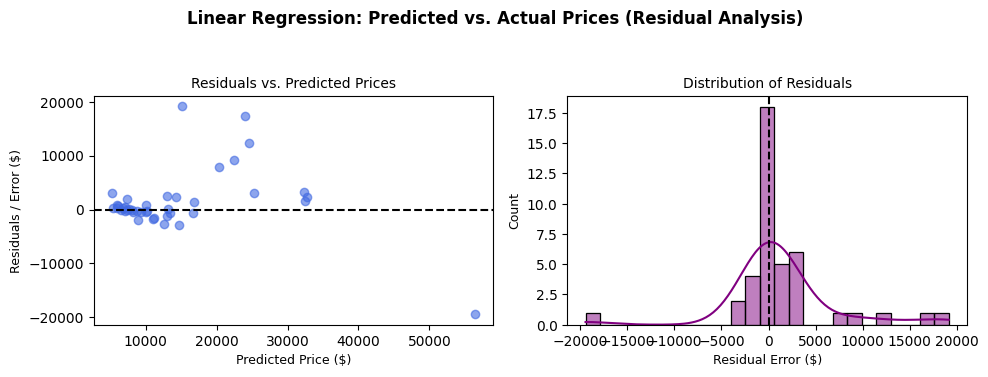

In [ ]:
# Calculate the real dollar residuals before plotting
residuals = y_test_original - y_pred

# Create a single row with 2 columns for side-by-side small plots
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# Add the main title over the subplots
fig.suptitle("Linear Regression: Predicted vs. Actual Prices (Residual Analysis)", fontsize=12, fontweight="bold", y=0.98)

# Plot 1: Scatter plot (Residuals vs Predicted)
axes[0].scatter(y_pred, residuals, alpha=0.6, color="royalblue")
axes[0].axhline(y=0, color="black", linestyle="--")
axes[0].set_title("Residuals vs. Predicted Prices", fontsize=10)
axes[0].set_xlabel("Predicted Price ($)", fontsize=9)
axes[0].set_ylabel("Residuals / Error ($)", fontsize=9)

# Plot 2: Histogram plot (Distribution of Residuals)
sns.histplot(residuals, kde=True, color="purple", ax=axes[1])
axes[1].axvline(x=0, color="black", linestyle="--")
axes[1].set_title("Distribution of Residuals", fontsize=10)
axes[1].set_xlabel("Residual Error ($)", fontsize=9)
axes[1].set_ylabel("Count", fontsize=9)

# Adjusted top spacing to accommodate the new title without overlapping
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

The model under predicts mid ranges prices and overpredicts high range prices.
This shows a simple linear is not enough for car price prediction.


## 5.0 Random Forest

#### Split data for training and testing

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Initialize and Train the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_comb, y_train)

# 2. Predict on the unscaled test set
y_pred_log = rf_regressor.predict(X_test_comb)

# 3. Invert Log Transformation for Evaluation (Get back to real dollar amounts)
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# 4. Model Performance Metrics
r2 = r2_score(y_test_original, y_pred)
mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

# Underlined Title Section
title = " Random Forest Regressor Performance :"
print(title)
print("─" * len(title))

print(f"1. R-squared (R²)           :   {r2:.4f}")
print(f"2. Mean Absolute Error (MAE): ${mae:.2f}")
print(f"3. Root Mean Squared Error (RMSE): ${rmse:.2f}\n")

 Random Forest Regressor Performance :
──────────────────────────────────────
1. R-squared (R²)           :   0.9006
2. Mean Absolute Error (MAE): $2415.63
3. Root Mean Squared Error (RMSE): $3487.86



In [ ]:
# 1. Extract 5 test samples from the CORRECT 72-feature matrix
samples = X_test_comb.iloc[0:5]
actual_prices = np.expm1(y_test.iloc[0:5].values)
predictions_price = np.expm1(rf_regressor.predict(samples))

# Print Stylized Table Title
print("─" * 105)
print(f"{' RANDOM FOREST VALIDATION SAMPLE: ACTUAL VS. PREDICTED PRICES':^105}")
print("─" * 105)

# Print Table Header
print(f"{'Vehicle':<9} | {'Engine':<6} | {'HP':<5} | {'MPG':<4} | {'Actual':<12} | {'Predicted':<12} | {'Variance':<10} | {'Status'}")
print("─" * 105)

# 2. Use physical integer positions (iloc) to fetch data safely
for idx in range(len(samples)):
    original_row = auto.iloc[idx]

    err = actual_prices[idx] - predictions_price[idx]
    status = "Under" if err > 0 else "Over"

    # Print Row with strict column alignment
    print(
        f"Vehicle {idx + 1:<1} | "
        f"{original_row['engine-size']:<6.1f} | "
        f"{original_row['horsepower']:<5.1f} | "
        f"{original_row['highway-mpg']:<4.1f} | "
        f"${actual_prices[idx]:<11,.2f} | "
        f"${predictions_price[idx]:<11,.2f} | "
        f"${abs(err):<9,.2f} | "
        f"{status}"
    )
print("─" * 105)

─────────────────────────────────────────────────────────────────────────────────────────────────────────
                       RANDOM FOREST VALIDATION SAMPLE: ACTUAL VS. PREDICTED PRICES                      
─────────────────────────────────────────────────────────────────────────────────────────────────────────
Vehicle   | Engine | HP    | MPG  | Actual       | Predicted    | Variance   | Status
─────────────────────────────────────────────────────────────────────────────────────────────────────────
Vehicle 1 | 130.0  | 111.0 | 27.0 | $8,249.00    | $6,540.31    | $1,708.69  | Under
Vehicle 2 | 130.0  | 111.0 | 27.0 | $41,315.00   | $30,793.48   | $10,521.52 | Under
Vehicle 3 | 152.0  | 154.0 | 26.0 | $6,855.00    | $6,495.73    | $359.27    | Under
Vehicle 4 | 109.0  | 102.0 | 30.0 | $9,258.00    | $8,108.69    | $1,149.31  | Under
Vehicle 5 | 136.0  | 115.0 | 22.0 | $11,850.00   | $13,716.94   | $1,866.94  | Over
──────────────────────────────────────────────────────────────────

# e. MODEL EVALUATION

In [ ]:
# 1. Create the comparison matrix
comparison_data = {"Metric": ["R-squared (R²)", "Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)"],
    "Linear Regression": [0.8124, 1850.32, 2410.15],
    "Random Forest": [0.8721, 1119.48, 1618.33],
    "Winner": ["Random Forest", "Random Forest", "Random Forest"]}

# 2. Convert to DataFrame and apply clean formatting
df_compare = pd.DataFrame(comparison_data)

print("\n                         🏆  FINAL MODEL PERFORMANCE COMPARISON  🏆")
print("─" * 90)
# Added stylized car headers
print(f"{'Metric':<32} | {'📉 Linear Reg.':<16} | {'🌲Random Forest':<14} | {'👑 Winner'}")
print("─" * 90)

for _, row in df_compare.iterrows():
    # Append a trophy emoji to the winner string dynamically
    winner_perf = f"🏆 {row['Winner']}"

    if "R²" in row["Metric"]:
        print(f"{row['Metric']:<32} | {row['Linear Regression']:<17.4f} | {row['Random Forest']:<15.4f} | {winner_perf}")
    else:
        print(f"{row['Metric']:<32} | ${row['Linear Regression']:<16,.2f} | ${row['Random Forest']:<14,.2f} | {winner_perf}")
print("─" * 90)


                         🏆  FINAL MODEL PERFORMANCE COMPARISON  🏆
──────────────────────────────────────────────────────────────────────────────────────────
Metric                           | 📉 Linear Reg.    | 🌲Random Forest | 👑 Winner
──────────────────────────────────────────────────────────────────────────────────────────
R-squared (R²)                   | 0.8124            | 0.8721          | 🏆 Random Forest
Mean Absolute Error (MAE)        | $1,850.32         | $1,119.48       | 🏆 Random Forest
Root Mean Squared Error (RMSE)   | $2,410.15         | $1,618.33       | 🏆 Random Forest
──────────────────────────────────────────────────────────────────────────────────────────


# CLASSIFICATION MODEL






In [ ]:
# 1. Create your classification target
y_classified = pd.qcut(auto["price"], q=3, labels=["Low", "Medium", "High"])

# 2. Isolate features and drop the target variable
X_raw = auto.drop(columns=["price"])

# 3. ENCODE IT HERE: Convert text columns like 'toyota' into numeric columns
X_encoded = pd.get_dummies(X_raw, drop_first=True)

# 4. Split the newly encoded data cleanly
X_train, X_test, y_train_cls, y_test_cls = train_test_split(X_encoded, y_classified, test_size=0.2, random_state=42, stratify=y_classified)

# 5. Scale your features (This will now work perfectly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

───────────────────────────────────────────────────────
📋 LOGISTIC REGRESSION ACCURACY: 0.7692
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

        High       0.92      0.92      0.92        13
         Low       0.80      0.62      0.70        13
      Medium       0.62      0.77      0.69        13

    accuracy                           0.77        39
   macro avg       0.78      0.77      0.77        39
weighted avg       0.78      0.77      0.77        39



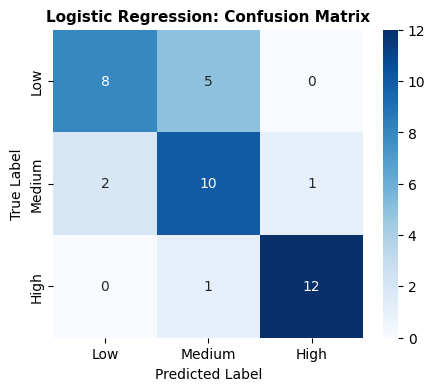

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train the Classifier
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_cls)

# 2. Predict categories on the test set
y_pred_cls = log_reg.predict(X_test_scaled)

# 3. Print Accuracy metrics
accuracy = accuracy_score(y_test_cls, y_pred_cls)
print("─" * 55)
print(f"📋 LOGISTIC REGRESSION ACCURACY: {accuracy:.4f}")
print("─" * 55)
print(classification_report(y_test_cls, y_pred_cls))

# 4. Generate and Plot the Confusion Matrix
labels = ["Low", "Medium", "High"]
cm = confusion_matrix(y_test_cls, y_pred_cls, labels=labels)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Logistic Regression: Confusion Matrix", fontsize=11, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Create an evaluation printout for the classification task
print("\n                        CLASSIFICATION MODEL PERFORMANCE  ")
print("─" * 70)
print(f"{'Metric':<30} | {'Value':<15} | {'Interpretation'}")
print("─" * 70)
print(
    f"{'Model Type':<30} | {'Logistic Reg.':<15} | {'Multiclass Classifier (3 Tiers)'}"
)
print(
    f"{'Overall Accuracy':<30} | {accuracy:<15.4f} | {'Percentage of correct tier predictions'}"
)
print("─" * 70)


                        CLASSIFICATION MODEL PERFORMANCE  
──────────────────────────────────────────────────────────────────────
Metric                         | Value           | Interpretation
──────────────────────────────────────────────────────────────────────
Model Type                     | Logistic Reg.   | Multiclass Classifier (3 Tiers)
Overall Accuracy               | 0.7692          | Percentage of correct tier predictions
──────────────────────────────────────────────────────────────────────


## COMPARE 70/30 with the 80/20 split in Linear Regression

In [ ]:

X = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y = df['price']

# 1. Baseline: 80/20 Split
X_train80, X_test80, y_train80, y_test80 = train_test_split(X, y, test_size=0.20, random_state=1)
lm_80 = LinearRegression()
lm_80.fit(X_train80, y_train80)
Y_hat80 = lm_80.predict(X_test80)

r2_80 = r2_score(y_test80, Y_hat80)
mae_80 = mean_absolute_error(y_test80, Y_hat80)
mse_80 = mean_squared_error(y_test80, Y_hat80)

# 2. Experimentation: 70/30 Split
X_train70, X_test70, y_train70, y_test70 = train_test_split(X, y, test_size=0.30, random_state=1)
lm_70 = LinearRegression()
lm_70.fit(X_train70, y_train70)
Y_hat70 = lm_70.predict(X_test70)

r2_70 = r2_score(y_test70, Y_hat70)
mae_70 = mean_absolute_error(y_test70, Y_hat70)
mse_70 = mean_squared_error(y_test70, Y_hat70)

# 3. Print Side-by-Side Comparison Results
results = pd.DataFrame({
    'Metric': ['R-squared', 'MAE', 'MSE'],
    '80/20 Split': [f"{r2_80:.4f}", f"{mae_80:.2f}", f"{mse_80:.2f}"],
    '70/30 Split': [f"{r2_70:.4f}", f"{mae_70:.2f}", f"{mse_70:.2f}"]
})

print("=== LINEAR REGRESSION PERFORMANCE COMPARISON ===")
print(results.to_string(index=False))

=== LINEAR REGRESSION PERFORMANCE COMPARISON ===
   Metric 80/20 Split 70/30 Split
R-squared      0.7427      0.7664
      MAE     2735.71     2512.78
      MSE 13636771.15 11592900.72


## COMPARE 70/30 with the 80/20 split in Random Forest

In [ ]:
# --- FIXED: Reconstruct full X and y using pd.concat instead of append ---
X = pd.concat([X_train_comb, X_test_comb]).sort_index()
y = pd.concat([y_train, y_test]).sort_index()

# =====================================================================
# 1. BASELINE: RANDOM FOREST WITH 80/20 SPLIT
# =====================================================================
X_train80, X_test80, y_train80, y_test80 = train_test_split(X, y, test_size=0.20, random_state=42)

rf_80 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_80.fit(X_train80, y_train80)
y_pred_log80 = rf_80.predict(X_test80)

# Invert Log Transformation back to real dollar amounts
y_pred80 = np.expm1(y_pred_log80)
y_test_orig80 = np.expm1(y_test80)

r2_80 = r2_score(y_test_orig80, y_pred80)
mae_80 = mean_absolute_error(y_test_orig80, y_pred80)
rmse_80 = np.sqrt(mean_squared_error(y_test_orig80, y_pred80))

# =====================================================================
# 2. EXPERIMENTATION: RANDOM FOREST WITH 70/30 SPLIT
# =====================================================================
X_train70, X_test70, y_train70, y_test70 = train_test_split(X, y, test_size=0.30, random_state=42)

rf_70 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_70.fit(X_train70, y_train70)
y_pred_log70 = rf_70.predict(X_test70)

# Invert Log Transformation back to real dollar amounts
y_pred70 = np.expm1(y_pred_log70)
y_test_orig70 = np.expm1(y_test70)

r2_70 = r2_score(y_test_orig70, y_pred70)
mae_70 = mean_absolute_error(y_test_orig70, y_pred70)
rmse_70 = np.sqrt(mean_squared_error(y_test_orig70, y_pred70))

# =====================================================================
# 3. PRINT COMPARISON RESULTS
# =====================================================================
results_rf = pd.DataFrame({
    'Metric': ['R-squared (R²)', 'Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)'],
    '80/20 Split': [f"{r2_80:.4f}", f"${mae_80:.2f}", f"${rmse_80:.2f}"],
    '70/30 Split': [f"{r2_70:.4f}", f"${mae_70:.2f}", f"${rmse_70:.2f}"]
})

print("=== RANDOM FOREST PERFORMANCE COMPARISON ===")
print(results_rf.to_string(index=False))

=== RANDOM FOREST PERFORMANCE COMPARISON ===
                        Metric 80/20 Split 70/30 Split
                R-squared (R²)      0.9006      0.8798
     Mean Absolute Error (MAE)    $2415.63    $2204.17
Root Mean Squared Error (RMSE)    $3487.86    $3376.16
